# General notebook

In [33]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


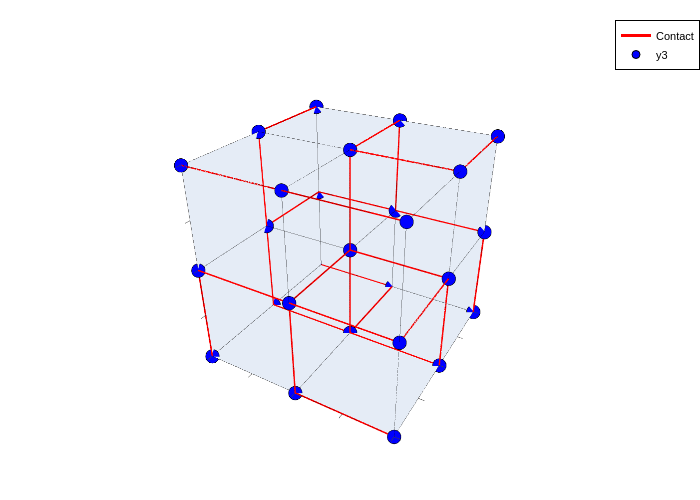

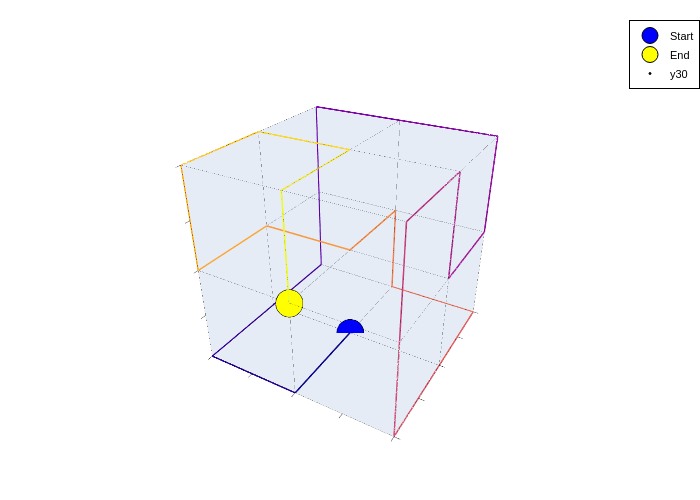

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:42


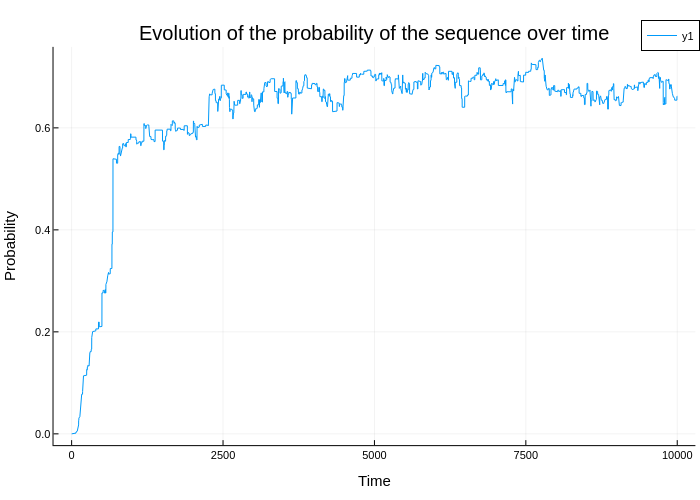

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


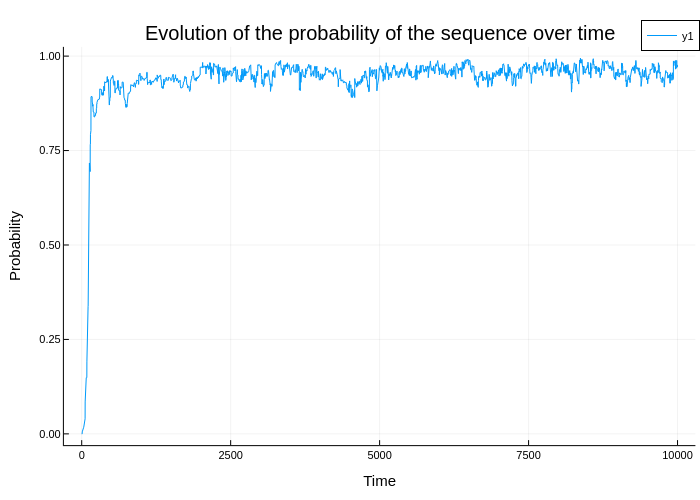

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:01


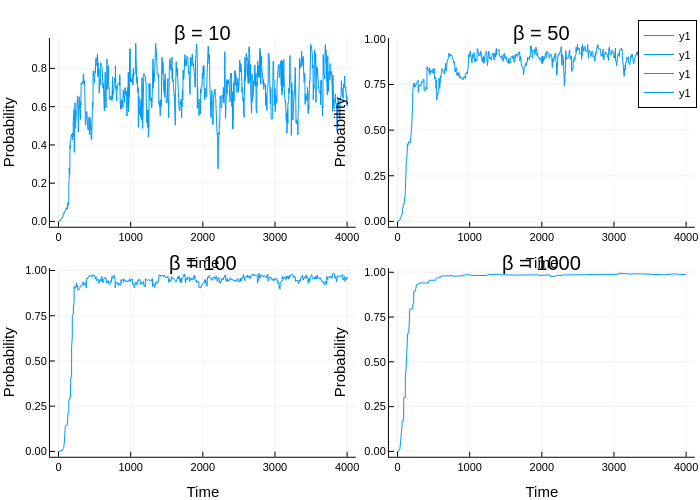

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([4, 15, 14, 5, 18, 11, 5, 16, 6, 5  …  6, 2, 18, 13, 16, 7, 12, 18…
  10.0   => ([4, 5, 14, 16, 10, 8, 14, 1, 16, 12  …  18, 19, 19, 16, 4, 19, 4, …
  1000.0 => ([14, 14, 4, 15, 10, 19, 19, 18, 5, 15  …  2, 19, 19, 15, 2, 15, 1,…
  100.0  => ([4, 4, 16, 1, 16, 20, 1, 18, 16, 14  …  19, 14, 5, 8, 6, 18, 1, 5,…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:12


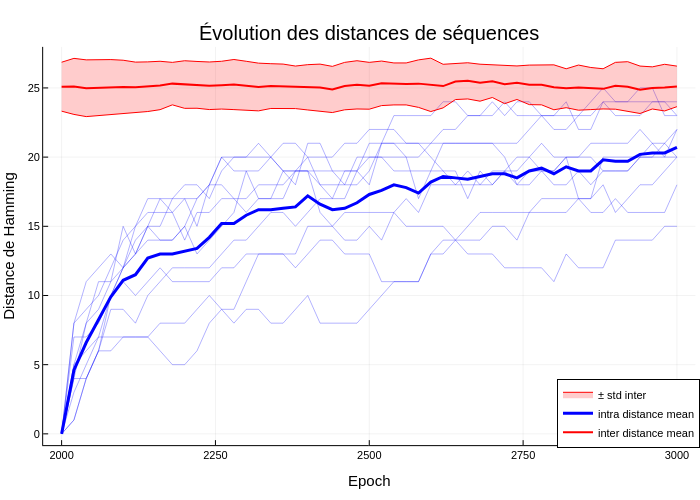

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


structure 1234 : 0.951496268622396
structure 529 : 0.014268235390525295
structure 3103 : 0.002358523446937705
structure 2398 : 0.002243496901101998
structure 5097 : 0.002243496901101998
structure 2332 : 0.0016620233823793256
structure 1288 : 0.001580965545527393
structure 5072 : 0.0014305167822188485
structure 1797 : 0.001430516782218833
structure 561 : 0.0013607496554886675
structure 1315 : 0.001294385111679996
structure 3084 : 0.0011712080823967127
structure 1289 : 0.0011140875901887992
structure 1123 : 0.0008676522876491769
structure 1233 : 0.0008253363862472648
structure 2732 : 0.0007467952447431031
structure 1117 : 0.0006757282810548813
structure 1230 : 0.0005262577144290436
structure 4977 : 0.0005262577144290411
structure 2849 : 0.0005262577144290358


### Mutations on the cube

In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 21
  16 => 23
  20 => 9
  12 => 32
  24 => 31
  8  => 36
  17 => 25
  1  => 37
  23 => 23
  22 => 15
  19 => 26
  6  => 35
  11 => 31
  9  => 14
  14 => 26
  3  => 33
  7  => 9
  25 => 14
  13 => 29
  ⋮  => ⋮

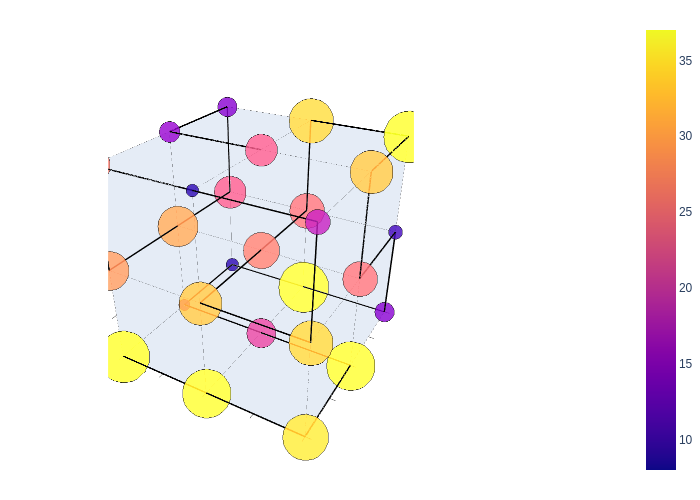

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[target_number], n_mutations_per_position)

In [11]:
beta = 100
target_number = 1234
epoch_start, epoch_stop, step = 2000, 10000, 200

paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
all_ctc_maps = all_contact_maps(paths_reduced)

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, epoch_stop, beta, epoch_start, step)
println("On a sauvegardé $(length(saved_seq)) structures.")

plot_gif_cube_with_mutations(x, y, z, lx, ly, lz, PATHS[target_number], saved_seq)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


On a sauvegardé 41 structures.


┌ Info: Saved animation to /home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/mutations.gif
└ @ Plots /home/gabriel/.julia/packages/Plots/xC48f/src/animation.jl:156


GIF sauvegardé : ../figures/mutations.gif


## Tree generation

In [12]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println(proba_final_root)

newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps, beta=100 )

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


0.9706371781840902
((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : GLN SER VAL LYS ARG CYS GLU ILE LYS LYS ILE LYS CYS CYS CYS ILE LYS ASN GLY ASP LYS VAL HIS ALA LEU GLU MET
N4 : ASP ASP PHE LYS ARG ALA ASP PHE ARG ASN ALA LYS CYS CYS LEU ILE ARG ASP PRO GLU ARG MET ASN PHE PHE THR VAL
N5 : TYR GLU GLN LYS ARG ILE ASP TYR ARG CYS GLN LYS ILE LYS LEU LEU ARG ASP CYS GLU LYS VAL ARG VAL ILE THR PHE
N7 : VAL GLU GLN LYS ARG GLY ASP ASP LYS CYS ASP LYS PHE LYS VAL ILE LYS ASP ALA GLU LYS VAL ASN SER LEU GLN SER
N1 : ASN ASP CYS LYS ARG MET GLU ASP ASP TRP GLN LYS LEU CYS MET PHE ARG ASP ARG GLU ARG VAL ARG ALA LEU GLU LEU
N6 : ASN ASP LEU LYS LYS LYS ASP MET LYS CYS TYR ASN PHE LYS MET VAL ARG ASP CYS GLU LYS VAL GLN LEU PHE ASP VAL
N2 : TRP VAL ASP LYS ARG MET ASP GLU ASN PRO GLN LYS VAL CYS LEU ILE ARG ASP ASP GLU ARG VAL ARG PHE PHE SER LEU


In [13]:
N1= seq_dict["N1"]
N3 = seq_dict["N3"]
println(hamming_distance(N1,N3))

18


In [14]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     21    22    18    18    23    21    
N4    21    0     17    19    18    19    14    
N5    22    17    0     15    18    17    16    
N7    18    19    15    0     19    17    19    
N1    18    18    18    19    0     19    14    
N6    23    19    17    17    19    0     20    
N2    21    14    16    19    14    20    0     


In [15]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [16]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [17]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : GLN ASP LEU LYS ARG GLY ASP ILE LYS ASN ILE LYS PHE CYS LEU ILE ARG ASP PRO GLU LYS VAL ASN LEU LEU GLN VAL
N2 : GLN ASP VAL LYS ARG ALA ASP ILE LYS ASN ILE LYS CYS CYS LEU ILE ARG ASP PRO GLU LYS VAL ASN ALA LEU GLU VAL
N3 : GLN SER VAL LYS ARG CYS GLU ILE LYS LYS ILE LYS CYS CYS CYS ILE LYS ASN GLY ASP LYS VAL HIS ALA LEU GLU MET
N4 : ASP ASP PHE LYS ARG ALA ASP PHE ARG ASN ALA LYS CYS CYS LEU ILE ARG ASP PRO GLU ARG MET ASN PHE PHE THR VAL
N5 : VAL ASP LEU LYS ARG GLY ASP ASP LYS CYS ASP LYS PHE LYS VAL ILE ARG ASP ALA GLU LYS VAL ASN LEU LEU GLN VAL
N6 : ASN ASP LEU LYS LYS LYS ASP MET LYS CYS TYR ASN PHE LYS MET VAL ARG ASP CYS GLU LYS VAL GLN LEU PHE ASP VAL
N7 : VAL GLU GLN LYS ARG GLY ASP ASP LYS CYS ASP LYS PHE LYS VAL ILE LYS ASP ALA GLU LYS VAL ASN SER LEU GLN SER


In [18]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))

"N1" => [13, 16, 5, 19, 18, 10, 16, 4, 19, 14  …  16, 20, 15, 19, 6, 14, 5, 5, 13, 6]

In [19]:
reconstruction_error_hamming(result, seq_dict)

17

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


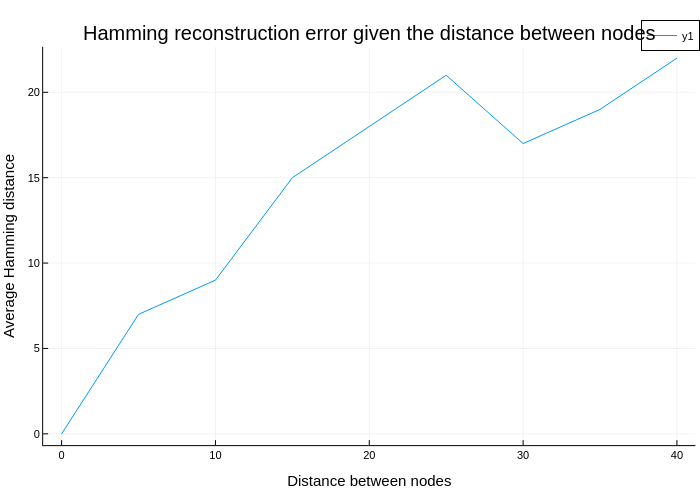

In [20]:
distance_btw_nodes = 0:5:40
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 4

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_hamming(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [21]:
reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number)

0.007866247699658047

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


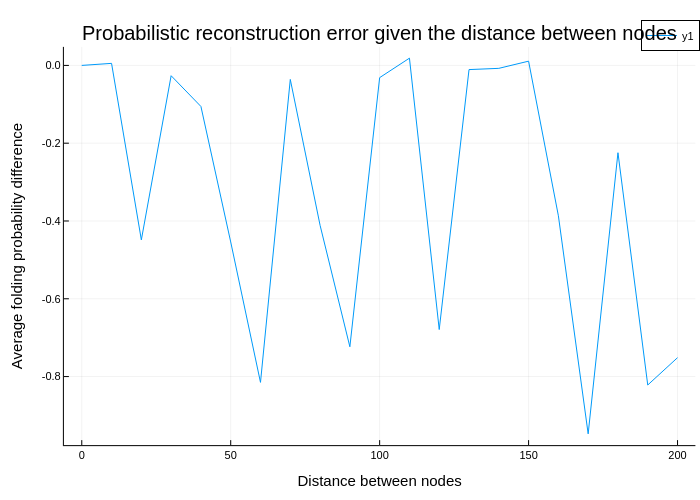

In [22]:
distance_btw_nodes = 0:10:200
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_proba(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [23]:
#IQ-TREE
#Voir consensus feuilles
#Faire moyenne plusieurs itérations

1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10
1
2
3
4
5
6
7
8
9
10


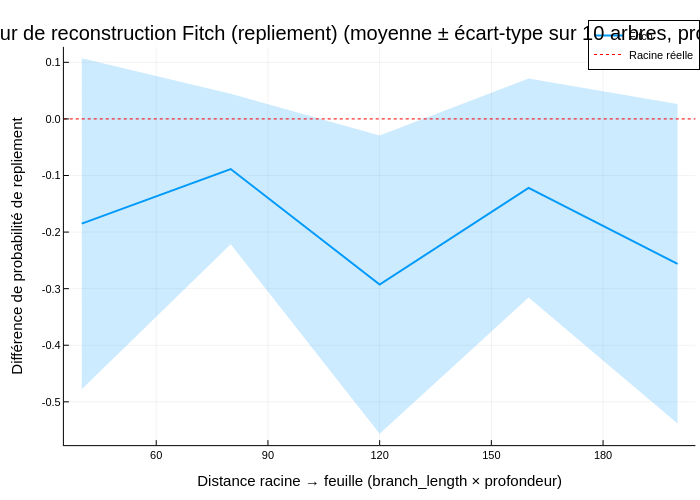

In [38]:
root_to_leaf_distances = [40, 80, 120, 160, 200]  # branch_length × profondeur
tree_depth = 2                                      # branch_length sera 20, 40, 60, 80, 100

p1 = plot_reconstruction_error_hamming(root_seq, root_to_leaf_distances, tree_depth, 10, target_number, all_ctc_maps)
p2 = plot_reconstruction_error_proba(root_seq, root_to_leaf_distances, tree_depth, 10, target_number, all_ctc_maps)

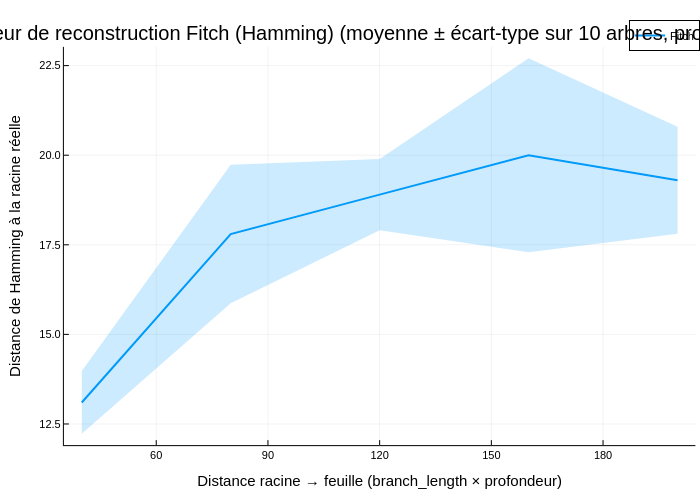

In [39]:
plot(p1)

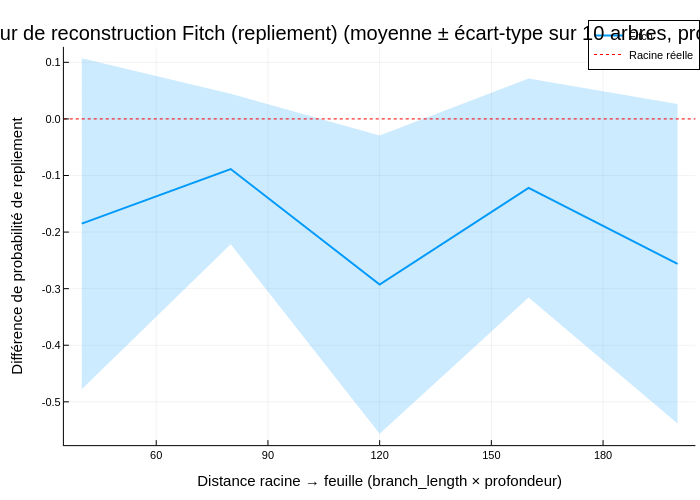

In [40]:
plot(p2)